# Лабораторная работа №1
## Базовые понятия машинного обучения

**Цель работы:** освоить базовые понятия машинного обучения, генерация случайной выборки, борьба с переобучением.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings('ignore')

---
## Часть 1. Загрузка датасета Iris и визуальный анализ

In [2]:
# Загрузка датасета Iris
# Датасет доступен по адресу: https://archive.ics.uci.edu/ml/datasets/iris
# Для удобства используем встроенную копию из sklearn
iris = load_iris()

df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f'Размер датасета: {df.shape}')
print(f'Классы: {list(iris.target_names)}')
df.head(10)

Размер датасета: (150, 5)
Классы: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# Описательная статистика
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


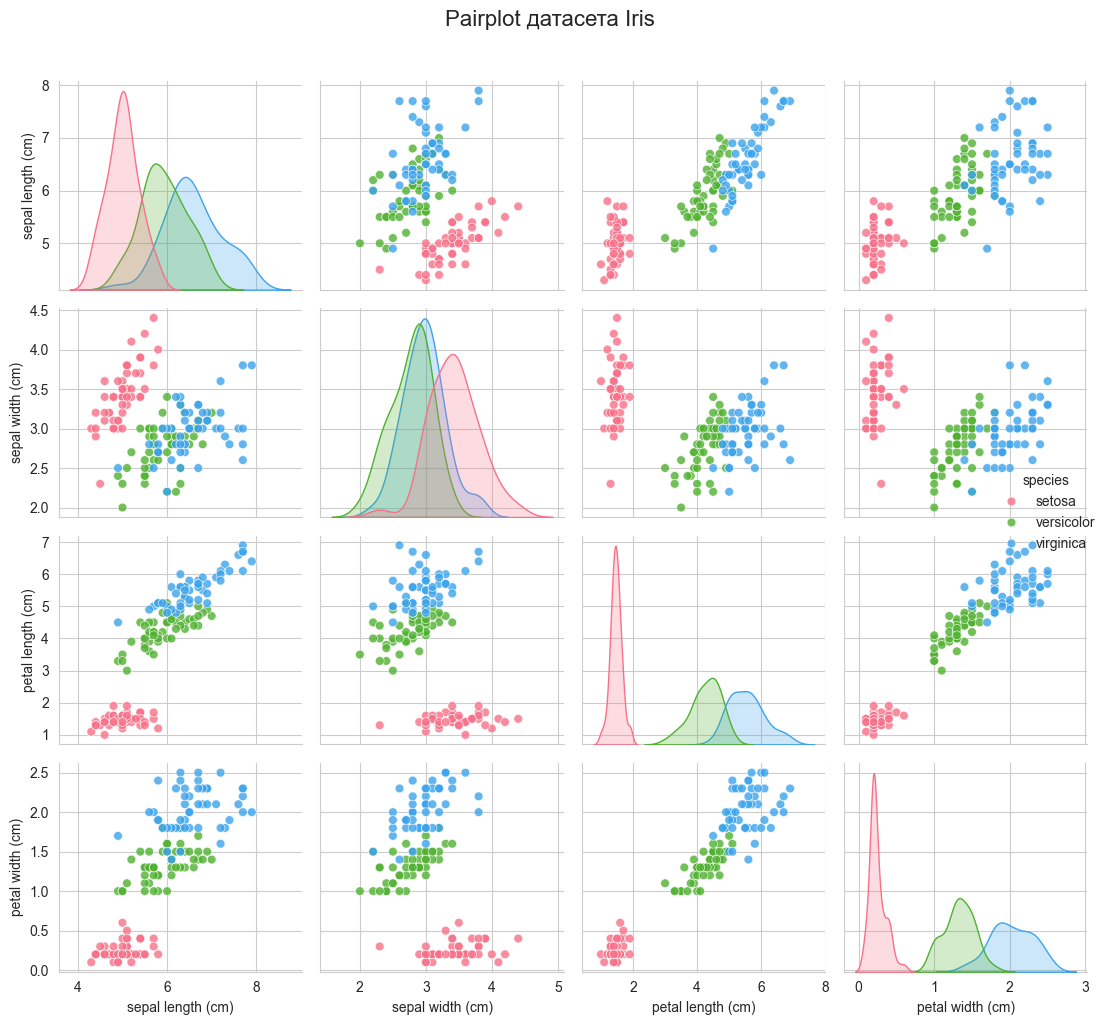

In [4]:
# Построение pairplot для визуального анализа данных
sns.set_style('whitegrid')
pairplot = sns.pairplot(df, hue='species', diag_kind='kde', 
                         palette='husl', height=2.5,
                         plot_kws={'alpha': 0.8, 's': 40})
pairplot.figure.suptitle('Pairplot датасета Iris', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**Выводы по pairplot:**
- Класс setosa чётко отделяется от двух других классов по большинству признаков.
- Классы versicolor и virginica частично перекрываются, особенно по признакам sepal length и sepal width.
- Наилучшее разделение классов наблюдается по признакам petal length и petal width.

---
## Часть 2. Логистическая регрессия для бинарной классификации

In [5]:
# Для бинарной классификации выберем два класса: versicolor (1) и virginica (2)
# Эти классы сложнее всего разделить, что делает задачу интереснее

mask = iris.target != 0  # исключаем setosa
X_bin = iris.data[mask]
y_bin = iris.target[mask]
# Перекодируем: versicolor=0, virginica=1
y_bin = (y_bin == 2).astype(int)

print(f'Размер выборки: {X_bin.shape}')
print(f'Распределение классов: versicolor={sum(y_bin==0)}, virginica={sum(y_bin==1)}')

Размер выборки: (100, 4)
Распределение классов: versicolor=50, virginica=50


In [6]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin, test_size=0.3, random_state=52, stratify=y_bin
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка: {X_test.shape[0]} объектов')

Обучающая выборка: 70 объектов
Тестовая выборка: 30 объектов


In [7]:
# Обучение модели логистической регрессии
log_reg = LogisticRegression(random_state=52, max_iter=200)
log_reg.fit(X_train, y_train)

# Предсказания
y_pred_train = log_reg.predict(X_train)
y_pred_test = log_reg.predict(X_test)

print('=== Результаты логистической регрессии ===')
print(f'Accuracy на обучающей выборке: {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Accuracy на тестовой выборке:  {accuracy_score(y_test, y_pred_test):.4f}')
print()
print('Отчёт классификации (тестовая выборка):')
print(classification_report(y_test, y_pred_test, 
                            target_names=['versicolor', 'virginica']))

=== Результаты логистической регрессии ===
Accuracy на обучающей выборке: 0.9714
Accuracy на тестовой выборке:  0.9000

Отчёт классификации (тестовая выборка):
              precision    recall  f1-score   support

  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



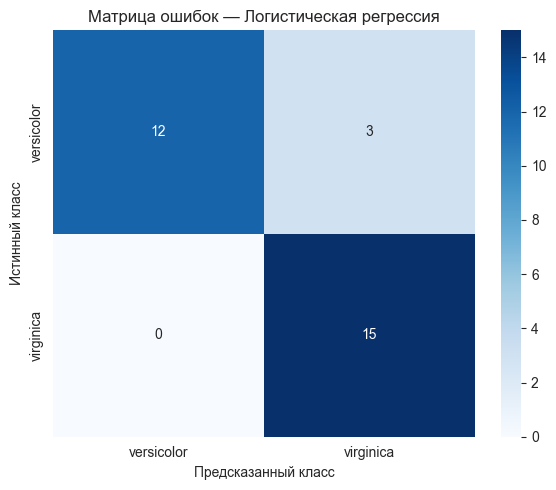

In [8]:
# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['versicolor', 'virginica'],
            yticklabels=['versicolor', 'virginica'], ax=ax)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title('Матрица ошибок — Логистическая регрессия')
plt.tight_layout()
plt.show()

**Вывод:** Логистическая регрессия хорошо справляется с бинарной классификацией versicolor/virginica. Accuracy на тестовой выборке показывает высокое качество модели.

---
## Часть 3. Демонстрация переобучения модели линейной регрессии

Для наглядной демонстрации переобучения сгенерируем синтетические данные и будем увеличивать степень полинома.

In [9]:
# Генерация синтетических данных
np.random.seed(52)
n_samples = 30

X_gen = np.sort(np.random.uniform(0, 1, n_samples))
# Истинная зависимость: sin(2*pi*x)
y_true_func = lambda x: np.cos(2 * np.pi * x)
y_gen = y_true_func(X_gen) + np.random.normal(0, 0.25, n_samples)

X_gen = X_gen.reshape(-1, 1)

# Разделение на train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_gen, y_gen, test_size=0.4, random_state=52
)

print(f'Обучающая выборка: {len(X_tr)} точек')
print(f'Тестовая выборка: {len(X_te)} точек')

Обучающая выборка: 18 точек
Тестовая выборка: 12 точек


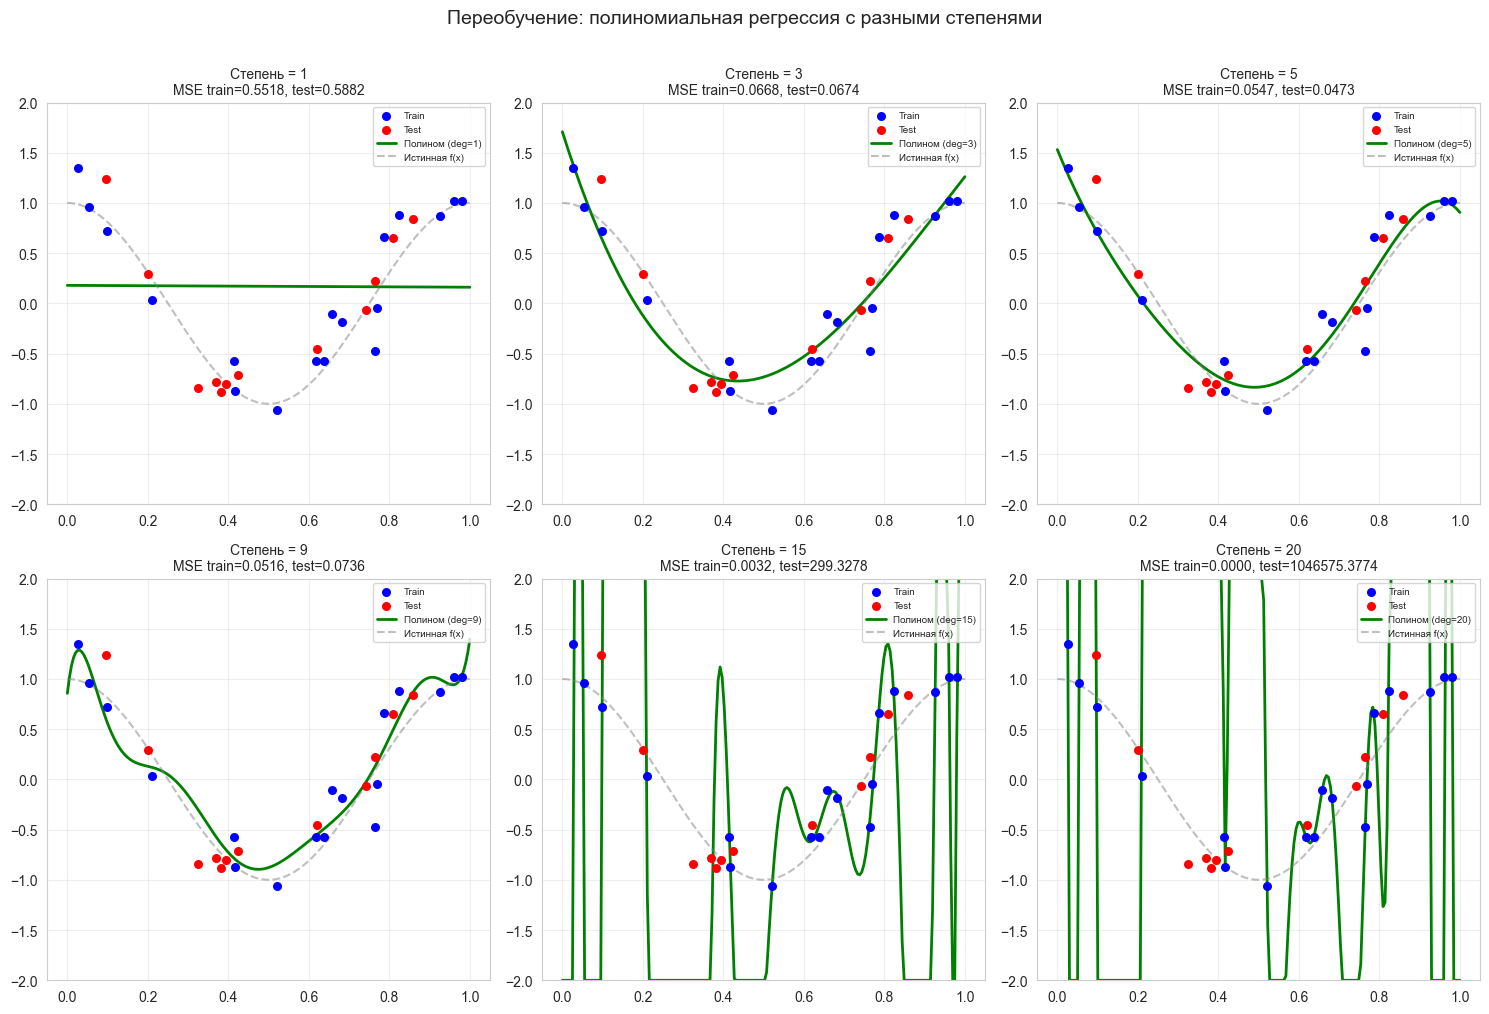

In [10]:
# Обучение полиномиальной регрессии с разными степенями
degrees = [1, 3, 5, 9, 15, 20]
train_errors = []
test_errors = []

X_plot = np.linspace(0, 1, 200).reshape(-1, 1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, degree in enumerate(degrees):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_tr, y_tr)
    
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
    
    mse_train = mean_squared_error(y_tr, y_pred_tr)
    mse_test = mean_squared_error(y_te, y_pred_te)
    train_errors.append(mse_train)
    test_errors.append(mse_test)
    
    # Визуализация
    ax = axes[i]
    ax.scatter(X_tr, y_tr, color='blue', s=30, label='Train', zorder=3)
    ax.scatter(X_te, y_te, color='red', s=30, label='Test', zorder=3)
    y_plot = model.predict(X_plot)
    # Ограничим диапазон для наглядности
    y_plot_clipped = np.clip(y_plot, -2, 2)
    ax.plot(X_plot, y_plot_clipped, color='green', linewidth=2, label=f'Полином (deg={degree})')
    ax.plot(X_plot, y_true_func(X_plot.ravel()), '--', color='gray', alpha=0.5, label='Истинная f(x)')
    ax.set_title(f'Степень = {degree}\nMSE train={mse_train:.4f}, test={mse_test:.4f}', fontsize=10)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Переобучение: полиномиальная регрессия с разными степенями', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

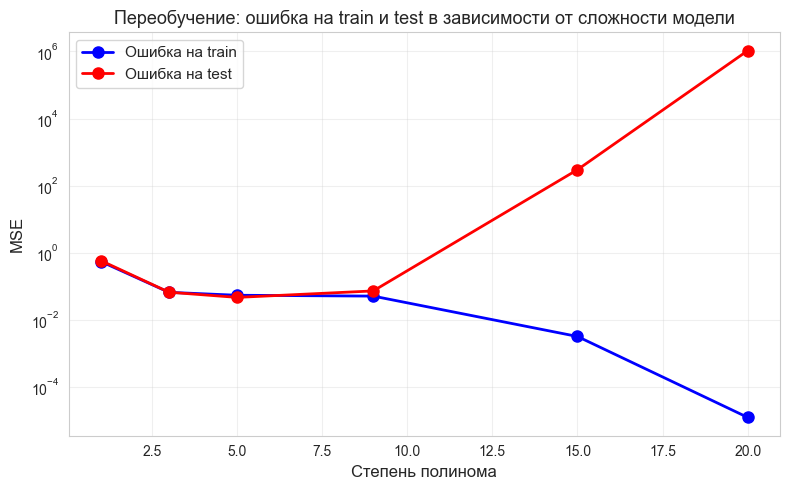

Таблица ошибок:
 Степень  MSE (train)   MSE (test)
       1     0.551845 5.882070e-01
       3     0.066832 6.739782e-02
       5     0.054700 4.725814e-02
       9     0.051626 7.358191e-02
      15     0.003242 2.993278e+02
      20     0.000013 1.046575e+06


In [11]:
# График зависимости ошибки от степени полинома
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(degrees, train_errors, 'bo-', label='Ошибка на train', linewidth=2, markersize=8)
ax.plot(degrees, test_errors, 'ro-', label='Ошибка на test', linewidth=2, markersize=8)
ax.set_xlabel('Степень полинома', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Переобучение: ошибка на train и test в зависимости от сложности модели', fontsize=13)
ax.legend(fontsize=11)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Таблица ошибок:')
err_df = pd.DataFrame({'Степень': degrees, 'MSE (train)': train_errors, 'MSE (test)': test_errors})
print(err_df.to_string(index=False))

**Наблюдение:** 
- При увеличении степени полинома ошибка на обучающей выборке уменьшается (модель всё лучше «запоминает» данные).
- При этом ошибка на тестовой выборке сначала уменьшается, а затем резко возрастает — это и есть переобучение (overfitting).
- Модель высокой степени идеально подгоняется под обучающие данные, но теряет способность обобщать на новые данные.

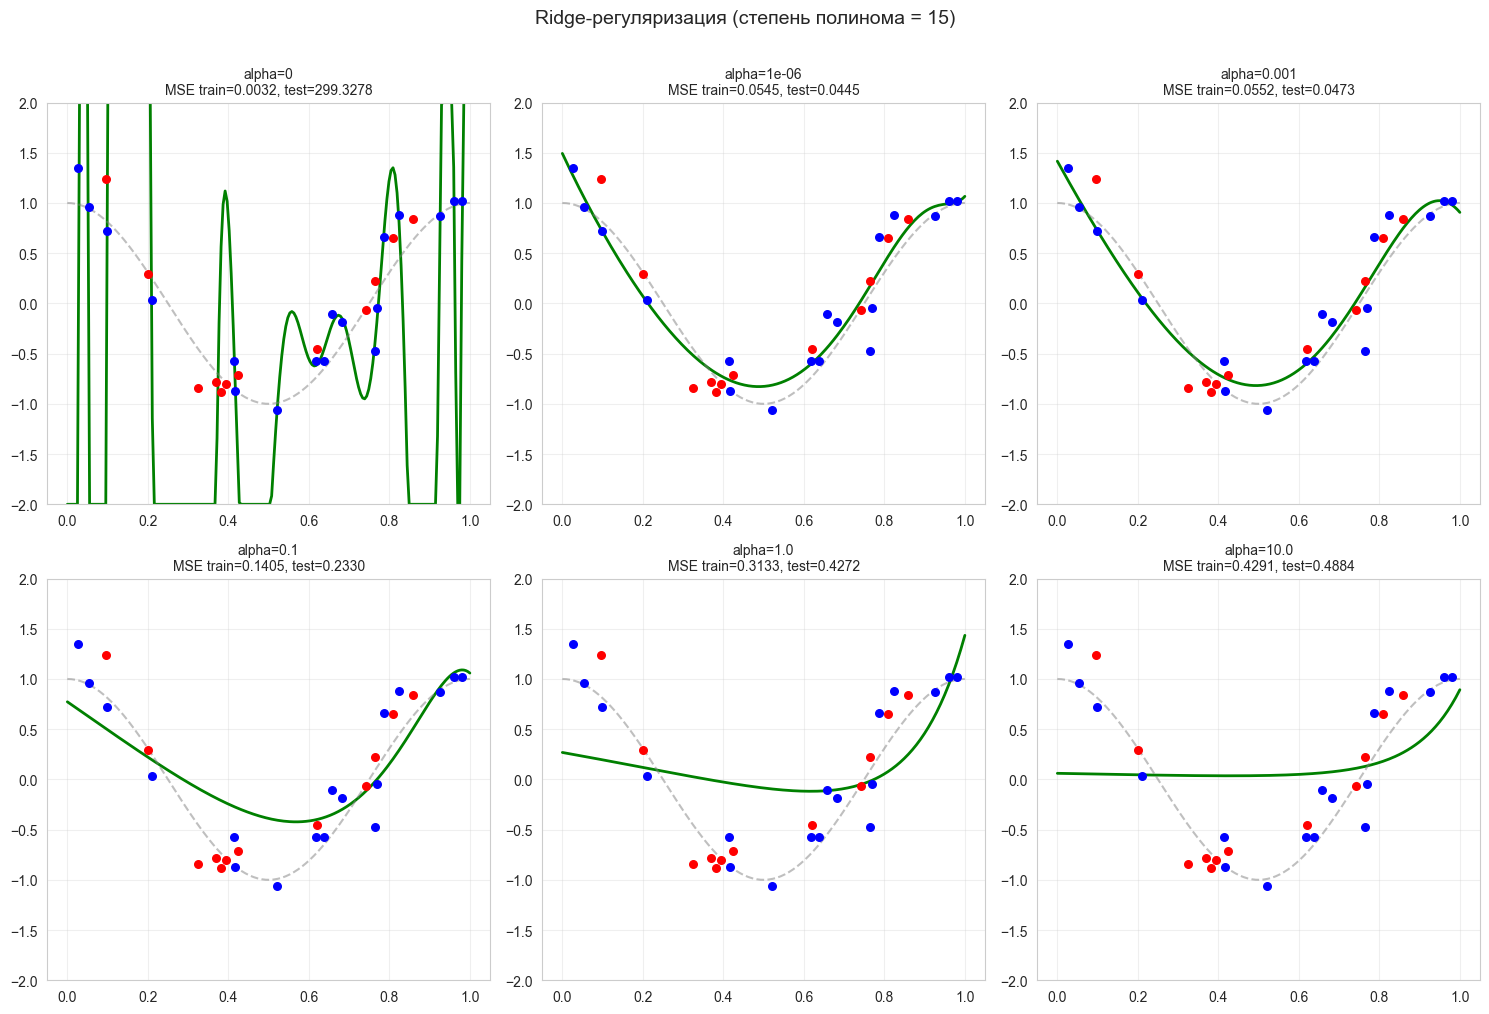

In [12]:
# Демонстрация регуляризации (Ridge) как метода борьбы с переобучением
degree_high = 15
alphas = [0, 1e-6, 1e-3, 0.1, 1.0, 10.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, alpha in enumerate(alphas):
    if alpha == 0:
        model = make_pipeline(PolynomialFeatures(degree_high), LinearRegression())
    else:
        model = make_pipeline(PolynomialFeatures(degree_high), Ridge(alpha=alpha))
    
    model.fit(X_tr, y_tr)
    mse_tr = mean_squared_error(y_tr, model.predict(X_tr))
    mse_te = mean_squared_error(y_te, model.predict(X_te))
    
    ax = axes[i]
    ax.scatter(X_tr, y_tr, color='blue', s=30, label='Train', zorder=3)
    ax.scatter(X_te, y_te, color='red', s=30, label='Test', zorder=3)
    y_plot = model.predict(X_plot)
    y_plot_clipped = np.clip(y_plot, -2, 2)
    ax.plot(X_plot, y_plot_clipped, color='green', linewidth=2)
    ax.plot(X_plot, y_true_func(X_plot.ravel()), '--', color='gray', alpha=0.5)
    ax.set_title(f'alpha={alpha}\nMSE train={mse_tr:.4f}, test={mse_te:.4f}', fontsize=10)
    ax.set_ylim(-2, 2)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Ridge-регуляризация (степень полинома = {degree_high})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Вывод по регуляризации:**
- Без регуляризации (alpha=0) полином 15-й степени сильно переобучается.
- С увеличением параметра alpha модель становится более «гладкой», борясь с переобучением.
- Оптимальное значение alpha обеспечивает баланс между точностью на train и обобщающей способностью на test.

---
## Теоретическая разминка

### 1. В чём состоит основная проблема переобучения?

Переобучение (overfitting) — это ситуация, когда модель слишком точно подстраивается под обучающие данные, «запоминая» шум и случайные особенности выборки вместо реальных закономерностей. В результате модель показывает высокое качество на обучающей выборке, но плохо работает на новых, ранее не виденных данных. Основная проблема — потеря способности к обобщению.

### 2. Почему мы не можем оценивать качество модели на тех данных, на которых она обучалась?

Если оценивать модель на обучающих данных, мы получим чрезмерно оптимистичную оценку качества. Модель может просто «запомнить» все примеры (как студент, заучивший ответы без понимания). Истинное качество модели — это её способность работать с новыми данными, поэтому необходимо выделять отдельную тестовую выборку, которая не участвовала в обучении.

### 3. Что такое регуляризация и как она помогает бороться со сложностью модели?

Регуляризация — это метод, который добавляет штраф за сложность модели к функции потерь. Например, L2-регуляризация (Ridge) добавляет сумму квадратов весов, а L1-регуляризация (Lasso) — сумму модулей весов. Это ограничивает величину коэффициентов модели, не позволяя им принимать чрезмерно большие значения. В результате модель становится проще и лучше обобщает, снижая переобучение.